In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import os
import seaborn as sb
from statistics import mean
style.use('fast')
def ROC_PR_AUC_Curves(Values_real,Value_infered, number_genes, file_path_data, algorithm, color_ROC="indigo", color_PR= "springgreen", show_plot=False):
    """
        This functions returns the area under the ROC and PR curve 
        and plots the tpr vs fpr and the precision vs recall.
    """
    
    #ROC
    fpr, tpr, thresholds = roc_curve(Values_real, Value_infered)
    AUC_ROC = auc(fpr, tpr)
    
    
    #PR
    precision, recall, thresholds = precision_recall_curve(Values_real, Value_infered)
    AUC_PR = auc(recall, precision)
    
    if show_plot==True:
        
        plt.rc('xtick', labelsize=22)    
        plt.rc('ytick', labelsize=22)    
        plt.rcParams["font.family"] = "serif"
    
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [0, 1], 'k--',  lw=2.8)
        plt.plot(fpr, tpr, lw=2.8, color=color_ROC,label='Area = {:.3f}'.format(AUC_ROC))
        plt.fill_between(fpr, tpr,color=color_ROC, alpha=0.28)
        plt.xlabel('False positive rate',family="serif",fontsize = 26)
        plt.ylabel('True positive rate',family="serif",fontsize = 26)
        plt.title(f'ROC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/ROC_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [1, 0], 'k--',  lw=2.8)
        plt.plot(recall, precision, lw=2.8, color=color_PR,label='Area = {:.3f}'.format(AUC_PR))
        plt.fill_between(recall, precision,color=color_PR, alpha=0.28)
        plt.xlabel('Recall',family="serif",fontsize = 26)
        plt.ylabel('Precision',family="serif",fontsize = 26)
        plt.title(f'PRC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/PR_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
    
    return AUC_ROC, AUC_PR


In [2]:
AUROC_results = {}
AUPRC_results = {}

In_degree = [2,3,4]
Nodes = [10,20,50,100]
Algorithm = ["SWING", "dynGENIE3"]

for degree in In_degree:
    for nodes in Nodes:
        for algorithm in Algorithm:
            
            AUROC_results[f"AUROC_results_{nodes}genes_{algorithm}_{degree}_in_degree"] = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/Computing_Performance_{degree}_in_degree/AUROC_results_{nodes}genes_{algorithm}.txt", sep = '\t', header = None)
            AUPRC_results[f"AUPRC_results_{nodes}genes_{algorithm}_{degree}_in_degree"] = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/Computing_Performance_{degree}_in_degree/AUPRC_results_{nodes}genes_{algorithm}.txt", sep = '\t', header = None)
            
            AUROC_results[f"AUROC_results_{nodes}genes_{algorithm}_{degree}_in_degree_rand"] = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/Computing_Performance_{degree}_in_degree/AUROC_results_{nodes}genes_{algorithm}_rand.txt", sep = '\t', header = None)
            AUPRC_results[f"AUPRC_results_{nodes}genes_{algorithm}_{degree}_in_degree_rand"] = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/Computing_Performance_{degree}_in_degree/AUPRC_results_{nodes}genes_{algorithm}_rand.txt", sep = '\t', header = None)
        
            AUROC_results[f"AUROC_results_{nodes}genes_{algorithm}_{degree}_in_degree_crand"] = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/Computing_Performance_{degree}_in_degree/AUROC_results_{nodes}genes_{algorithm}_crand.txt", sep = '\t', header = None)
            AUPRC_results[f"AUPRC_results_{nodes}genes_{algorithm}_{degree}_in_degree_crand"] = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/Computing_Performance_{degree}_in_degree/AUPRC_results_{nodes}genes_{algorithm}_crand.txt", sep = '\t', header = None)
            
            AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"] = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/Computing_Performance_{degree}_in_degree/AUROC_results_{nodes}genes_random.txt", sep = '\t', header = None)
            AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"] = pd.read_csv(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/{degree}_in_degree_networks/Computing_Performance_{degree}_in_degree/AUPRC_results_{nodes}genes_random.txt", sep = '\t', header = None)
            

# 10 genes

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

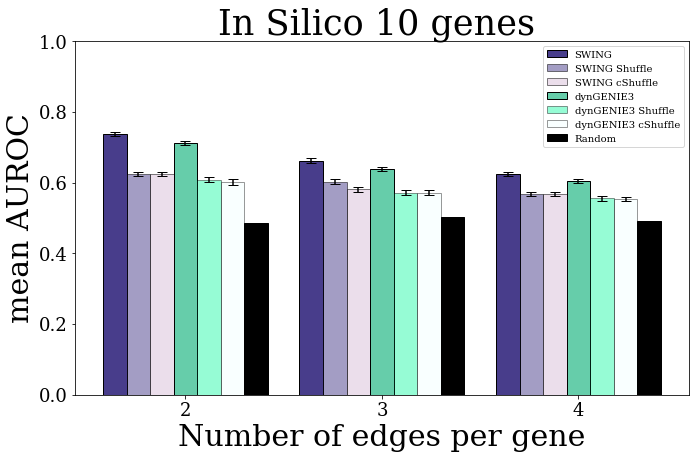

In [117]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

nodes = 10
In_degree = [2,3,4]
SWING = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for degree in In_degree]
SWING_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

SWING_rand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
SWING_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

SWING_crand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
SWING_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

dynGENIE3 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for degree in In_degree]
dynGENIE3_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

dynGENIE3_rand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
dynGENIE3_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

dynGENIE3_crand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
dynGENIE3_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

random = [AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for degree in In_degree]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], ["2", "3", "4"])#, "20", "50", "100"])
plt.title("In Silico 10 genes ", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2_3_4_10genes.png", bbox_inches="tight", dpi=100 )

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

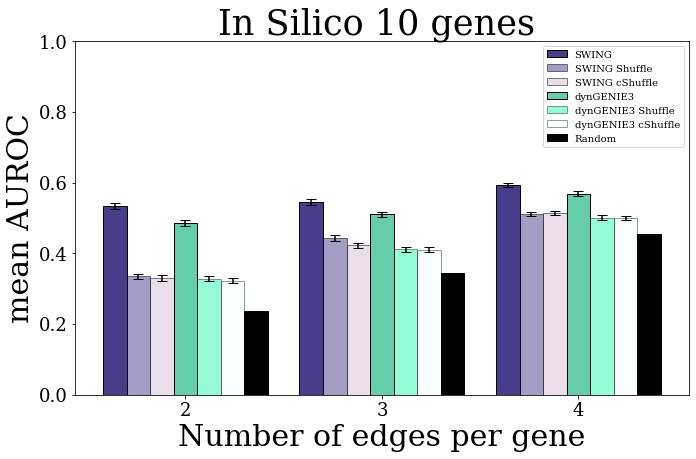

In [118]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

nodes = 10
In_degree = [2,3,4]
SWING = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for degree in In_degree]
SWING_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

SWING_rand = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
SWING_rand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

SWING_crand = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
SWING_crand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

dynGENIE3 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for degree in In_degree]
dynGENIE3_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

dynGENIE3_rand = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
dynGENIE3_rand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

dynGENIE3_crand = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
dynGENIE3_crand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

random = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for degree in In_degree]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], ["2", "3", "4"])#, "20", "50", "100"])
plt.title("In Silico 10 genes ", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2_3_4_10genes.png", bbox_inches="tight", dpi=100 )

# 20 genes

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

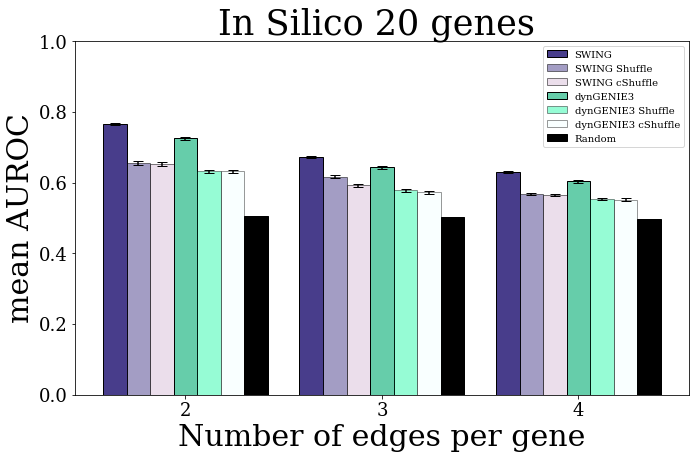

In [119]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

nodes = 20
In_degree = [2,3,4]
SWING = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for degree in In_degree]
SWING_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

SWING_rand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
SWING_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

SWING_crand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
SWING_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

dynGENIE3 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for degree in In_degree]
dynGENIE3_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

dynGENIE3_rand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
dynGENIE3_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

dynGENIE3_crand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
dynGENIE3_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

random = [AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for degree in In_degree]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], ["2", "3", "4"])#, "20", "50", "100"])
plt.title(f"In Silico {nodes} genes ", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2_3_4_10genes.png", bbox_inches="tight", dpi=100 )

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

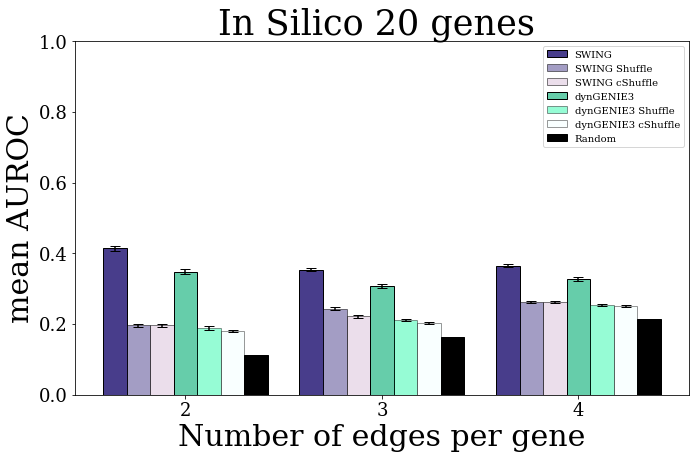

In [120]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

nodes = 20
In_degree = [2,3,4]
SWING = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for degree in In_degree]
SWING_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

SWING_rand = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
SWING_rand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

SWING_crand = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
SWING_crand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

dynGENIE3 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for degree in In_degree]
dynGENIE3_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

dynGENIE3_rand = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
dynGENIE3_rand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

dynGENIE3_crand = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
dynGENIE3_crand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

random = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for degree in In_degree]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], ["2", "3", "4"])#, "20", "50", "100"])
plt.title(f"In Silico {nodes} genes ", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2_3_4_10genes.png", bbox_inches="tight", dpi=100 )

# 50 genes

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

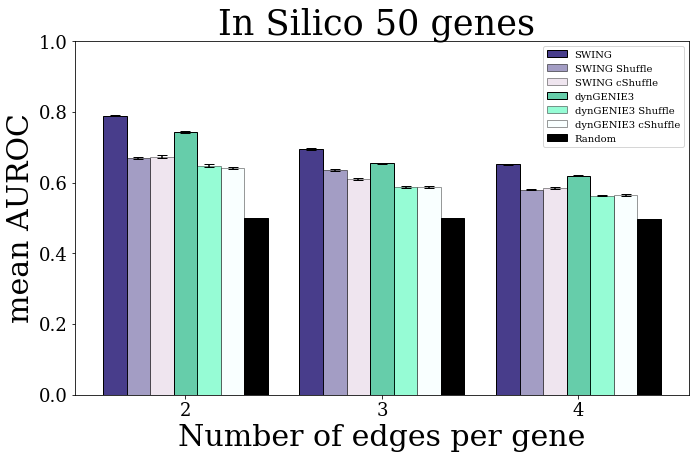

In [111]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

nodes = 50
In_degree = [2,3,4]
SWING = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for degree in In_degree]
SWING_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

SWING_rand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
SWING_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

SWING_crand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
SWING_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

dynGENIE3 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for degree in In_degree]
dynGENIE3_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

dynGENIE3_rand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
dynGENIE3_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

dynGENIE3_crand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
dynGENIE3_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

random = [AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for degree in In_degree]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], ["2", "3", "4"])#, "20", "50", "100"])
plt.title(f"In Silico {nodes} genes ", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2_3_4_10genes.png", bbox_inches="tight", dpi=100 )

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

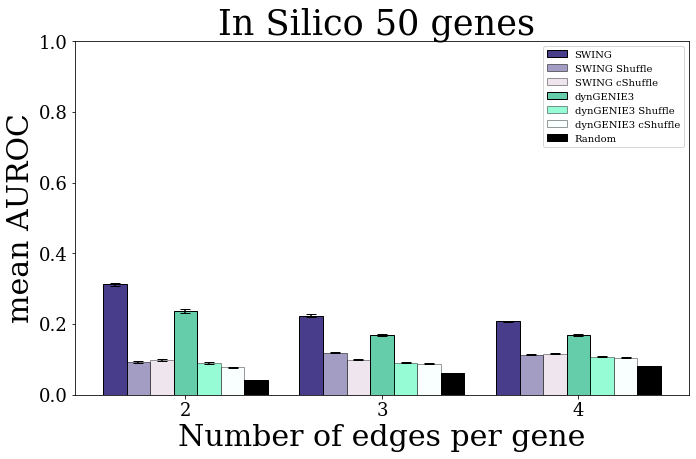

In [112]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

nodes = 50
In_degree = [2,3,4]
SWING = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for degree in In_degree]
SWING_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

SWING_rand = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
SWING_rand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

SWING_crand = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
SWING_crand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

dynGENIE3 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for degree in In_degree]
dynGENIE3_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

dynGENIE3_rand = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
dynGENIE3_rand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

dynGENIE3_crand = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
dynGENIE3_crand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

random = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for degree in In_degree]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], ["2", "3", "4"])#, "20", "50", "100"])
plt.title(f"In Silico {nodes} genes ", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2_3_4_10genes.png", bbox_inches="tight", dpi=100 )

# 100 genes

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

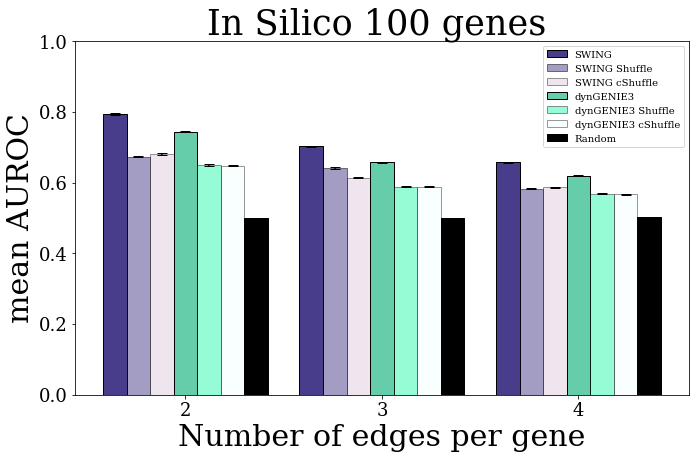

In [113]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

nodes = 100
In_degree = [2,3,4]
SWING = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for degree in In_degree]
SWING_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

SWING_rand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
SWING_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

SWING_crand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
SWING_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

dynGENIE3 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for degree in In_degree]
dynGENIE3_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

dynGENIE3_rand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
dynGENIE3_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

dynGENIE3_crand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
dynGENIE3_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

random = [AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for degree in In_degree]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], ["2", "3", "4"])#, "20", "50", "100"])
plt.title(f"In Silico {nodes} genes ", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2_3_4_10genes.png", bbox_inches="tight", dpi=100 )

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

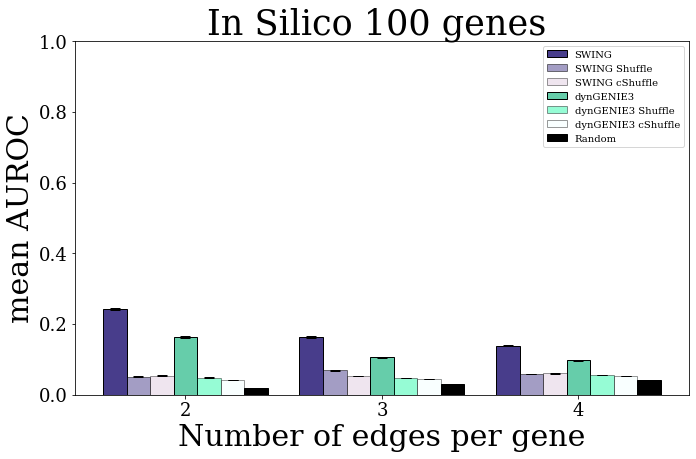

In [114]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

nodes = 100
In_degree = [2,3,4]
SWING = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for degree in In_degree]
SWING_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

SWING_rand = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
SWING_rand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

SWING_crand = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
SWING_crand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

dynGENIE3 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for degree in In_degree]
dynGENIE3_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

dynGENIE3_rand = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for degree in In_degree]
dynGENIE3_rand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for degree in In_degree]

dynGENIE3_crand = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for degree in In_degree]
dynGENIE3_crand_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for degree in In_degree]

random = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for degree in In_degree]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for degree in In_degree]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], ["2", "3", "4"])#, "20", "50", "100"])
plt.title(f"In Silico {nodes} genes ", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2_3_4_10genes.png", bbox_inches="tight", dpi=100 )

# Heat Map

# SWING

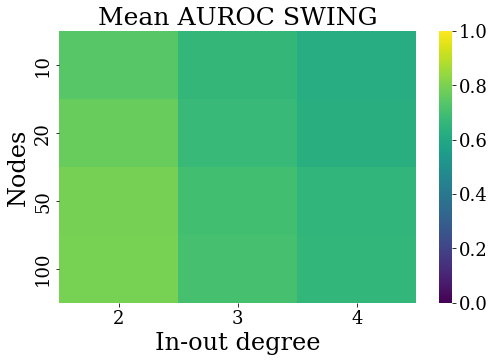

In [101]:
data = []
for nodes in Nodes:
    data.append([AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for degree in In_degree]) 

figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)



plt.rcParams["font.family"] = "serif"
sb.heatmap(data, cmap='viridis', vmin = 0, vmax = 1,fmt="Mean AUROC")
plt.xticks([0.5,1.5,2.5],["2", "3", "4"])
plt.yticks([0.5,1.5,2.5,3.5],["10","20","50","100"])
plt.ylabel('Nodes', family = 'serif',fontsize = 24)
plt.xlabel('In-out degree', family = 'serif',fontsize = 24)
plt.title(f"Mean AUROC SWING", fontsize = 25)
plt.show()

 

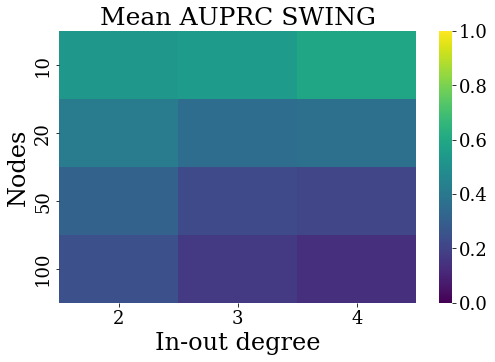

In [100]:
data = []
for nodes in Nodes:
    data.append([AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for degree in In_degree]) 

figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)

plt.rcParams["font.family"] = "serif"
sb.heatmap(data, cmap='viridis', vmin = 0, vmax = 1,fmt="Mean AUROC")
plt.xticks([0.5,1.5,2.5],["2", "3", "4"])
plt.yticks([0.5,1.5,2.5,3.5],["10","20","50","100"])
plt.ylabel('Nodes', family = 'serif',fontsize = 24)
plt.xlabel('In-out degree', family = 'serif',fontsize = 24)
plt.title(f"Mean AUPRC SWING", fontsize = 25)
plt.show()

# dynGENIE3

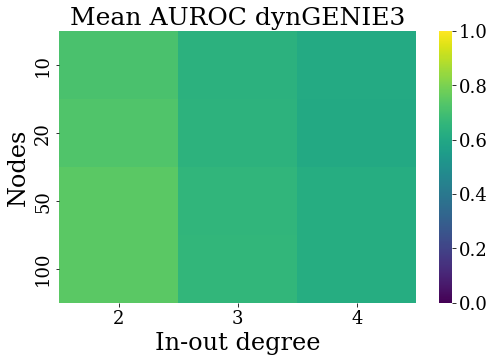

In [99]:
data = []
for nodes in Nodes:
    data.append([AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for degree in In_degree]) 

figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)

plt.rcParams["font.family"] = "serif"
sb.heatmap(data, cmap='viridis', vmin = 0, vmax = 1,fmt="Mean AUROC")
plt.xticks([0.5,1.5,2.5],["2", "3", "4"])
plt.yticks([0.5,1.5,2.5,3.5],["10","20","50","100"])
plt.ylabel('Nodes', family = 'serif',fontsize = 24)
plt.xlabel('In-out degree', family = 'serif',fontsize = 24)
plt.title(f"Mean AUROC dynGENIE3", fontsize = 25)
plt.show()

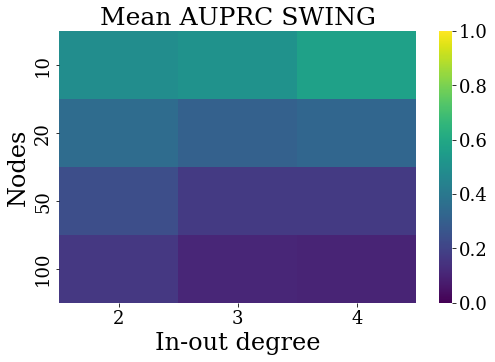

In [102]:
data = []
for nodes in Nodes:
    data.append([AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for degree in In_degree]) 

figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)

plt.rcParams["font.family"] = "serif"
sb.heatmap(data, cmap='viridis', vmin = 0, vmax = 1,fmt="Mean AUROC")
plt.xticks([0.5,1.5,2.5],["2", "3", "4"])
plt.yticks([0.5,1.5,2.5,3.5],["10","20","50","100"])
plt.ylabel('Nodes', family = 'serif',fontsize = 24)
plt.xlabel('In-out degree', family = 'serif',fontsize = 24)
plt.title(f"Mean AUPRC SWING", fontsize = 25)
plt.show()

# Overal Score

In [ ]:
(np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100) + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2) for degree in In_degree

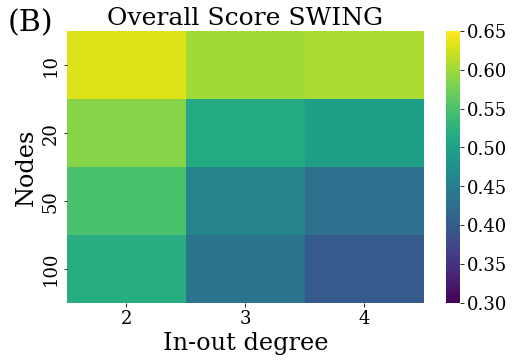

In [19]:
data = []
for nodes in Nodes:  
    data.append([ (np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_{degree}_in_degree"]),1/100)/2)[0] for degree in In_degree ]) 
    
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)

plt.rcParams["font.family"] = "serif"
sb.heatmap(data, cmap='viridis', vmin = 0.3, vmax = 0.65,fmt="Mean AUROC")
plt.xticks([0.5,1.5,2.5],["2", "3", "4"])
plt.yticks([0.5,1.5,2.5,3.5],["10","20","50","100"])
plt.ylabel('Nodes', family = 'serif',fontsize = 24)
plt.xlabel('In-out degree', family = 'serif',fontsize = 24)
plt.title(f"Overall Score SWING", fontsize = 25)
plt.text(-0.5,0, '(B)', family = "serif", fontsize= 30)
plt.show()

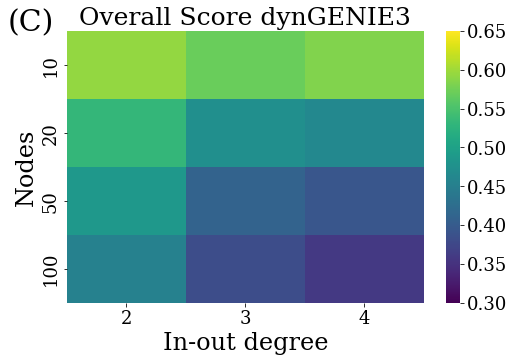

In [18]:
data = []
for nodes in Nodes:  
    data.append([ (np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2)[0] for degree in In_degree ]) 
    
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)

plt.rcParams["font.family"] = "serif"
sb.heatmap(data, cmap='viridis', vmin = 0.3, vmax = 0.65,fmt="Mean AUROC")
plt.xticks([0.5,1.5,2.5],["2", "3", "4"])
plt.yticks([0.5,1.5,2.5,3.5],["10","20","50","100"])
plt.ylabel('Nodes', family = 'serif',fontsize = 24)
plt.xlabel('In-out degree', family = 'serif',fontsize = 24)
plt.title(f"Overall Score dynGENIE3", fontsize = 25)
plt.text(-0.5,0, '(C)', family = "serif", fontsize= 30)
plt.show()

# Function of the nodes

## In degree 2

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

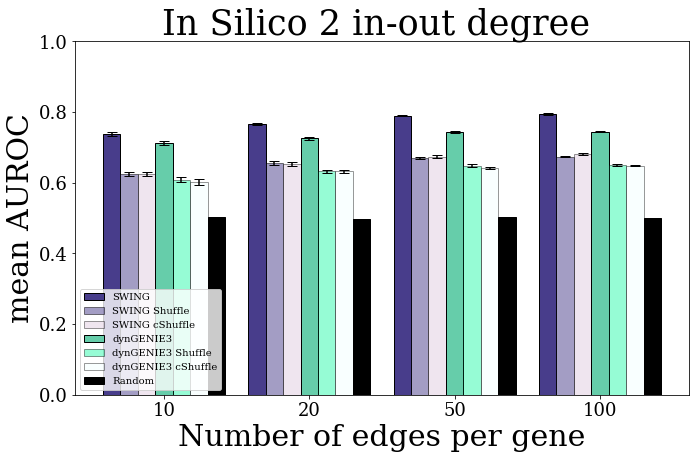

In [13]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

Nodes = [10,20,50,100]
degree = 2
SWING = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for nodes in Nodes]
SWING_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for nodes in Nodes]

SWING_rand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for nodes in Nodes]
SWING_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for nodes in Nodes]

SWING_crand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for nodes in Nodes]
SWING_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for nodes in Nodes]

dynGENIE3 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for nodes in Nodes]
dynGENIE3_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for nodes in Nodes]

dynGENIE3_rand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for nodes in Nodes]
dynGENIE3_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for nodes in Nodes]

dynGENIE3_crand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for nodes in Nodes]
dynGENIE3_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for nodes in Nodes]

random = [AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for nodes in Nodes]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for nodes in Nodes]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], Nodes)#, "20", "50", "100"])
plt.title(f"In Silico {degree} in-out degree ", fontsize = 35)
plt.legend(prop={"size":10})

plt.ylim(0,1)

## In degree 3

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

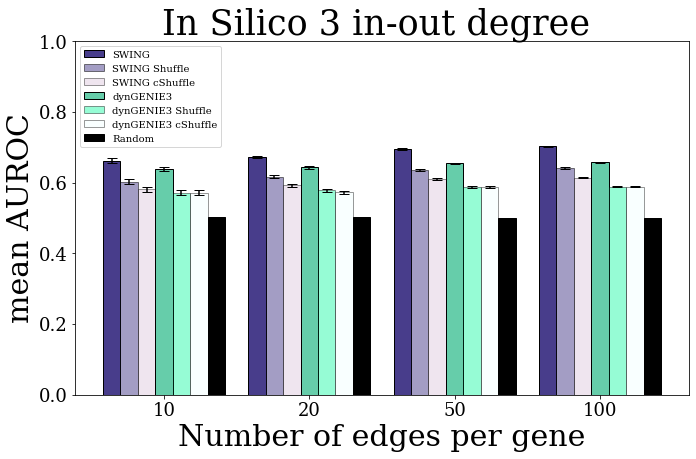

In [5]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

Nodes = [10,20,50,100]
degree = 3
SWING = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for nodes in Nodes]
SWING_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for nodes in Nodes]

SWING_rand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for nodes in Nodes]
SWING_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for nodes in Nodes]

SWING_crand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for nodes in Nodes]
SWING_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for nodes in Nodes]

dynGENIE3 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for nodes in Nodes]
dynGENIE3_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for nodes in Nodes]

dynGENIE3_rand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for nodes in Nodes]
dynGENIE3_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for nodes in Nodes]

dynGENIE3_crand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for nodes in Nodes]
dynGENIE3_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for nodes in Nodes]

random = [AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for nodes in Nodes]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for nodes in Nodes]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], Nodes)#, "20", "50", "100"])
plt.title(f"In Silico {degree} in-out degree ", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)

## In-degree 4

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

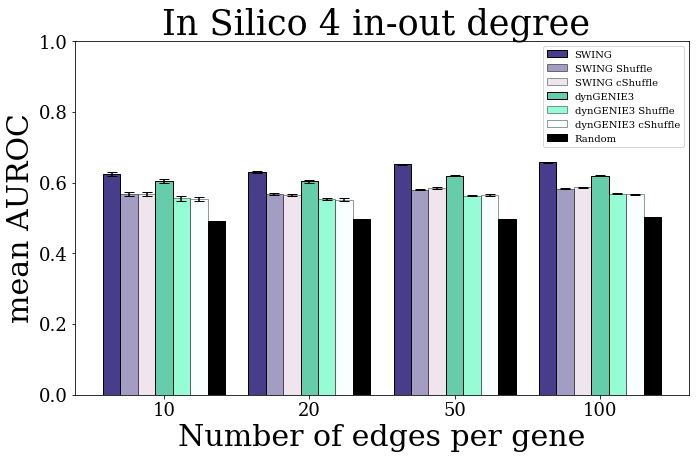

In [6]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

Nodes = [10,20,50,100]
degree = 4
SWING = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].mean()[0] for nodes in Nodes]
SWING_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree"].std()[0]/10 for nodes in Nodes]

SWING_rand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].mean()[0] for nodes in Nodes]
SWING_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_rand"].std()[0]/10 for nodes in Nodes]

SWING_crand = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].mean()[0] for nodes in Nodes]
SWING_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_{degree}_in_degree_crand"].std()[0]/10 for nodes in Nodes]

dynGENIE3 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].mean()[0] for nodes in Nodes]
dynGENIE3_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"].std()[0]/10 for nodes in Nodes]

dynGENIE3_rand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].mean()[0] for nodes in Nodes]
dynGENIE3_rand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_rand"].std()[0]/10 for nodes in Nodes]

dynGENIE3_crand = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].mean()[0] for nodes in Nodes]
dynGENIE3_crand_std = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree_crand"].std()[0]/10 for nodes in Nodes]

random = [AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"].mean()[0] for nodes in Nodes]
random_std = [AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"].std()[0]/10 for nodes in Nodes]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='thistle', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], Nodes)#, "20", "50", "100"])
plt.title(f"In Silico {degree} in-out degree ", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)

# Without considering the shuffle

### AUROC

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

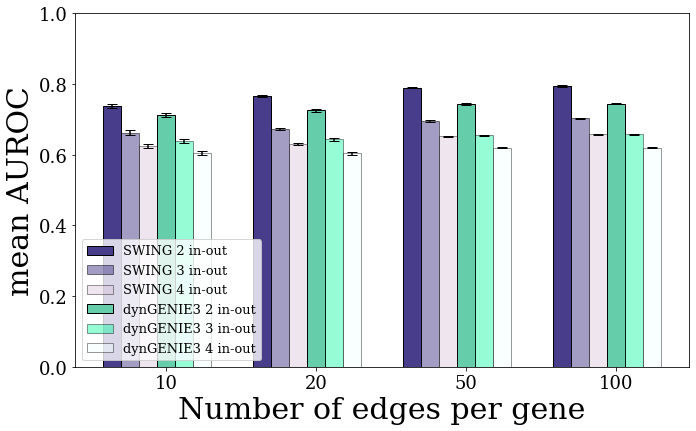

In [10]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

Nodes = [10,20,50,100]
degree = 4
SWING_2 = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_2_in_degree"].mean()[0] for nodes in Nodes]
SWING_std_2 = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_2_in_degree"].std()[0]/10 for nodes in Nodes]

dynGENIE3_2 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_2_in_degree"].mean()[0] for nodes in Nodes]
dynGENIE3_std_2 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_2_in_degree"].std()[0]/10 for nodes in Nodes]

SWING_3 = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_3_in_degree"].mean()[0] for nodes in Nodes]
SWING_std_3 = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_3_in_degree"].std()[0]/10 for nodes in Nodes]

dynGENIE3_3 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_3_in_degree"].mean()[0] for nodes in Nodes]
dynGENIE3_std_3 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_3_in_degree"].std()[0]/10 for nodes in Nodes]

SWING_4 = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_4_in_degree"].mean()[0] for nodes in Nodes]
SWING_std_4 = [AUROC_results[f"AUROC_results_{nodes}genes_SWING_4_in_degree"].std()[0]/10 for nodes in Nodes]

dynGENIE3_4 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_4_in_degree"].mean()[0] for nodes in Nodes]
dynGENIE3_std_4 = [AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_4_in_degree"].std()[0]/10 for nodes in Nodes]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING_2, yerr=SWING_std_2,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING 2 in-out')
plt.bar(br2, SWING_3, yerr=SWING_std_3,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING 3 in-out')
plt.bar(br3, SWING_4, yerr=SWING_std_4,capsize=5, align='center', color='thistle', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING 4 in-out')
plt.bar(br4, dynGENIE3_2, yerr=dynGENIE3_std_2,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3 2 in-out')
plt.bar(br5, dynGENIE3_3, yerr=dynGENIE3_std_3,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 3 in-out')
plt.bar(br6, dynGENIE3_4, yerr=dynGENIE3_std_4,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 4 in-out')


plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], Nodes)#, "20", "50", "100"])
#plt.title(f"In Silico {degree} in-out degree ", fontsize = 35)
plt.legend(prop={"size":13})
plt.ylim(0,1)

### AUPR

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

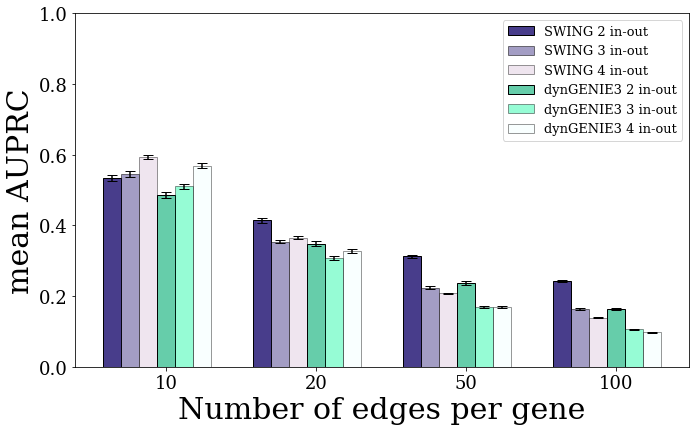

In [12]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

Nodes = [10,20,50,100]
degree = 4
SWING_2 = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_2_in_degree"].mean()[0] for nodes in Nodes]
SWING_std_2 = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_2_in_degree"].std()[0]/10 for nodes in Nodes]

dynGENIE3_2 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_2_in_degree"].mean()[0] for nodes in Nodes]
dynGENIE3_std_2 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_2_in_degree"].std()[0]/10 for nodes in Nodes]

SWING_3 = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_3_in_degree"].mean()[0] for nodes in Nodes]
SWING_std_3 = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_3_in_degree"].std()[0]/10 for nodes in Nodes]

dynGENIE3_3 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_3_in_degree"].mean()[0] for nodes in Nodes]
dynGENIE3_std_3 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_3_in_degree"].std()[0]/10 for nodes in Nodes]

SWING_4 = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_4_in_degree"].mean()[0] for nodes in Nodes]
SWING_std_4 = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_4_in_degree"].std()[0]/10 for nodes in Nodes]

dynGENIE3_4 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_4_in_degree"].mean()[0] for nodes in Nodes]
dynGENIE3_std_4 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_4_in_degree"].std()[0]/10 for nodes in Nodes]

labels = ["2", "3", "4"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING_2, yerr=SWING_std_2,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING 2 in-out')
plt.bar(br2, SWING_3, yerr=SWING_std_3,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING 3 in-out')
plt.bar(br3, SWING_4, yerr=SWING_std_4,capsize=5, align='center', color='thistle', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING 4 in-out')
plt.bar(br4, dynGENIE3_2, yerr=dynGENIE3_std_2,capsize=5, align='center', color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3 2 in-out')
plt.bar(br5, dynGENIE3_3, yerr=dynGENIE3_std_3,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 3 in-out')
plt.bar(br6, dynGENIE3_4, yerr=dynGENIE3_std_4,capsize=5, align='center', color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 4 in-out')


plt.ylabel('mean AUPRC', family = 'serif',fontsize = 30)
plt.xlabel('Number of edges per gene', family = 'serif',fontsize = 30)

plt.xticks([r + barWidth +0.24 for r in range(len(dynGENIE3))], Nodes)#, "20", "50", "100"])
#plt.title(f"In Silico {degree} in-out degree ", fontsize = 35)
plt.legend(prop={"size":13})
plt.ylim(0,1)

# Overall score

<Figure size 576x360 with 0 Axes>

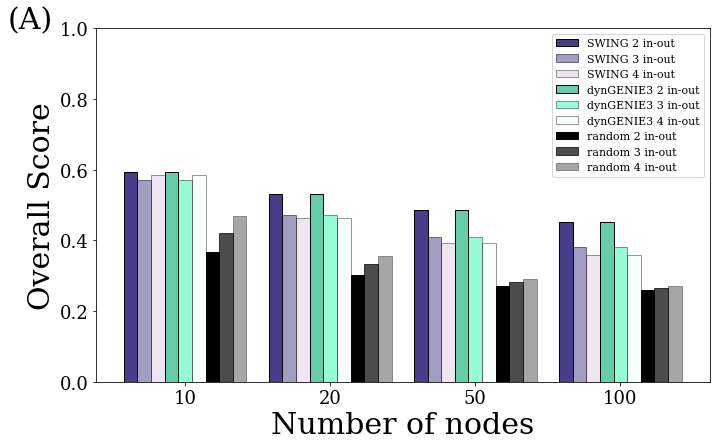

In [19]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

#AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"]
#AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"]

Nodes = [10,20,50,100]
degree = 2
SWING_2 = [(np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2)[0] for nodes in Nodes]
#SWING_std_2 = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_2_in_degree"].std()[0]/10 for nodes in Nodes]
dynGENIE3_2 = [(np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2)[0] for nodes in Nodes]
#dynGENIE3_std_2 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_2_in_degree"].std()[0]/10 for nodes in Nodes]
random_2 = [(np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"]),1/100)/2)[0] for nodes in Nodes]
#random_2_std = 

degree=3
SWING_3 = [(np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2)[0] for nodes in Nodes]
#SWING_std_3 = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_3_in_degree"].std()[0]/10 for nodes in Nodes]
dynGENIE3_3 = [(np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2)[0] for nodes in Nodes]
#dynGENIE3_std_3 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_3_in_degree"].std()[0]/10 for nodes in Nodes]
random_3 = [(np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"]),1/100)/2)[0] for nodes in Nodes]
#random_3_std = 

degree = 4
SWING_4 = [(np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2)[0] for nodes in Nodes]
#SWING_std_4 = [AUPRC_results[f"AUPRC_results_{nodes}genes_SWING_4_in_degree"].std()[0]/10 for nodes in Nodes]
dynGENIE3_4 = [(np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_{degree}_in_degree"]),1/100)/2)[0] for nodes in Nodes]
#dynGENIE3_std_4 = [AUPRC_results[f"AUPRC_results_{nodes}genes_dynGENIE3_4_in_degree"].std()[0]/10 for nodes in Nodes]
random_4 = [(np.power(np.prod(AUROC_results[f"AUROC_results_{nodes}genes_random_{degree}_in_degree"]),1/100)/2 + np.power(np.prod(AUPRC_results[f"AUPRC_results_{nodes}genes_random_{degree}_in_degree"]),1/100)/2)[0] for nodes in Nodes]
#random_4_std = 


labels = ["2", "3", "4"]
barWidth = 0.094

# Set position of bar on X axis
br1 = np.arange(len(SWING_2))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]
br8 = [x + barWidth for x in br7]
br9 = [x + barWidth for x in br8]

plt.figure(figsize=(11,6.5))

# Make the plot

plt.bar(br1, SWING_2, color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING 2 in-out')
plt.bar(br2, SWING_3, color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING 3 in-out')
plt.bar(br3, SWING_4, color='thistle', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING 4 in-out')
plt.bar(br4, dynGENIE3_2, color='mediumaquamarine', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3 2 in-out')
plt.bar(br5, dynGENIE3_3, color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 3 in-out')
plt.bar(br6, dynGENIE3_4, color='azure', alpha = 0.4,width= barWidth, edgecolor= 'k', label='dynGENIE3 4 in-out')
plt.bar(br7, random_2, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='random 2 in-out')
plt.bar(br8, random_3, color='k', alpha = 0.7,width= barWidth, edgecolor= 'k', label='random 3 in-out')
plt.bar(br9, random_4, color='k', alpha = 0.35,width= barWidth, edgecolor= 'k', label='random 4 in-out')

plt.ylabel('Overall Score', family = 'serif',fontsize = 30)
plt.xlabel('Number of nodes', family = 'serif',fontsize = 30)
plt.text(-0.85,1, '(A)', family = "serif", fontsize= 30)
plt.xticks([r + barWidth +0.28 for r in range(len(dynGENIE3_2))], Nodes)#, "20", "50", "100"])
plt.legend(prop={"size":11}, loc ="best")
plt.ylim(0,1)
plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Imagenes Internship/Overall_score_SWING_dynGENIE3.png", bbox_inches="tight", dpi=100 )